
--- Zone Outdoor Surface Count ---
HALL_DOWNSTAIRS: 3
FRONT_ROOM: 2
KITCHEN: 4
BACKROOM: 3
BEDROOM_3: 3
BEDROOM_1: 2
HALL_UPSTAIRS: 1
BATHROOM: 3
BEDROOM_2: 2
SUBFLOOR: 6
LOFT: 3

--- Infiltration/Exfiltration Comparison Table ---
                 AFN_infil  AFN_exfil  Eplus_infil  Measured_infil  \
Zone                                                                 
HALL_DOWNSTAIRS      2.221      0.000        2.425            2.02   
FRONT_ROOM           1.490      0.000        1.562            0.23   
KITCHEN              3.682      0.000        3.861            1.65   
BACKROOM             3.496      0.000        3.591            0.55   
BEDROOM_3            0.000      2.496        0.000            0.15   
BEDROOM_1            0.000      6.360        0.000            0.00   
HALL_UPSTAIRS        0.000      0.457        0.000            0.02   
BATHROOM             0.000      3.709        0.000            0.02   
BEDROOM_2            0.000      2.467        0.000            0.00  

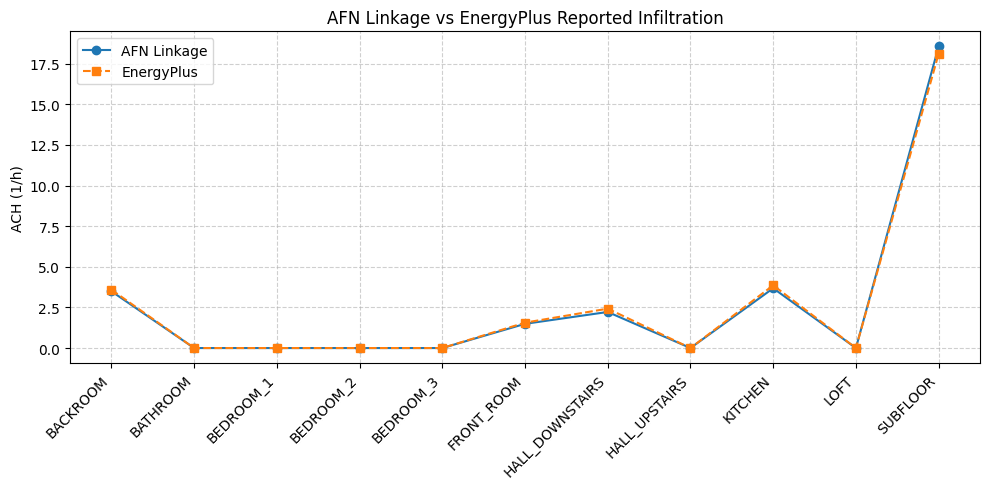

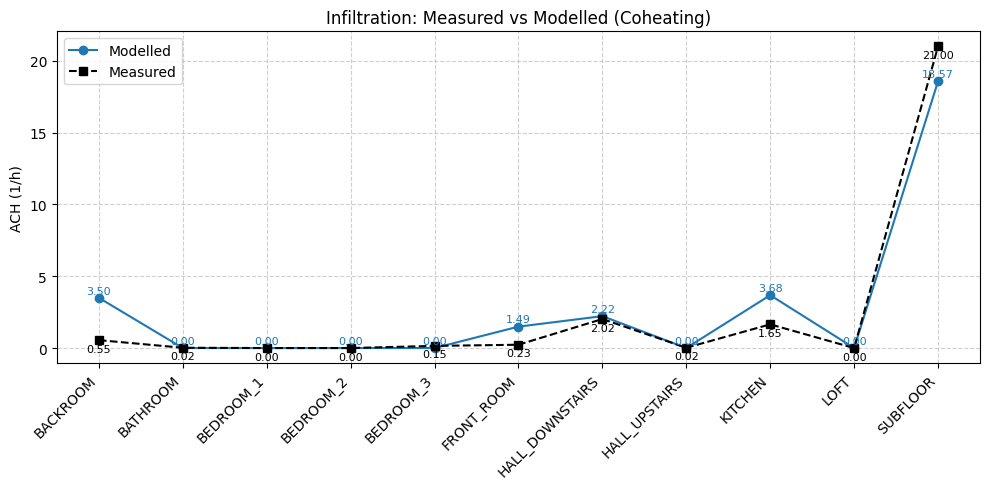

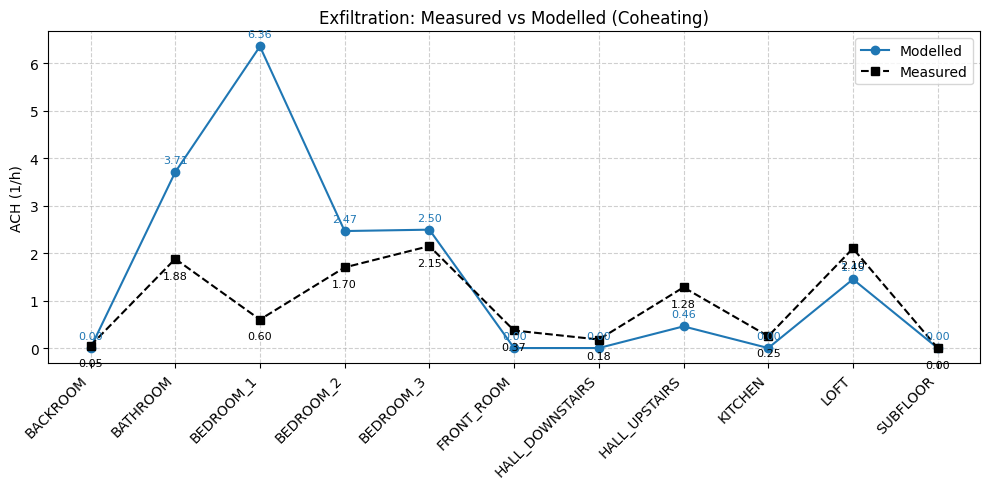

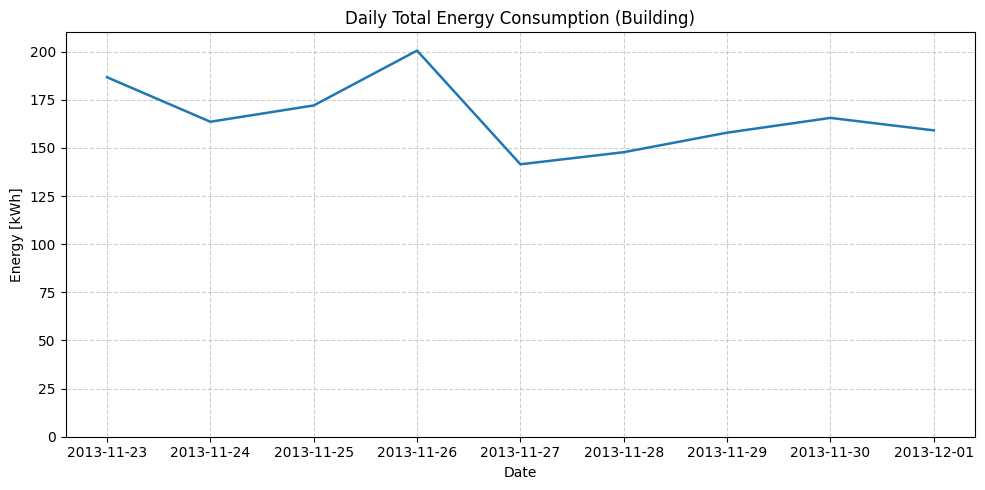

In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from eppy.modeleditor import IDF

# --- CONFIGURATION ---
idf_path = "/workspaces/CUBES/beizaee_validation/h28_coheat.idf"
coheat_csv = "/workspaces/CUBES/beizaee_validation/coheat/output/eplusout.csv"
idd_path = "/usr/local/EnergyPlus-9-5-0/Energy+.idd"

IDF.setiddname(idd_path)
idf = IDF(idf_path)

zone_volumes = {
    'HALL_DOWNSTAIRS':19.66,'FRONT_ROOM':39.31,'KITCHEN':31.75,'BACKROOM':31.75,
    'BEDROOM_1':32.21,'BEDROOM_2':34.69,'BEDROOM_3':19.21,'HALL_UPSTAIRS':16.46,
    'BATHROOM':19.89,'SUBFLOOR':8.75,'LOFT':50.30
}

measured_inf = {"FRONT_ROOM":0.23,"BACKROOM":0.55,"KITCHEN":1.65,"HALL_DOWNSTAIRS":2.02,"HALL_UPSTAIRS":0.02,"BEDROOM_1":0.0,"BEDROOM_2":0.0,"BEDROOM_3":0.15,"BATHROOM":0.02,"SUBFLOOR":21.0,"LOFT":0.0}
measured_exf = {"FRONT_ROOM":0.37,"BACKROOM":0.05,"KITCHEN":0.25,"HALL_DOWNSTAIRS":0.18,"HALL_UPSTAIRS":1.28,"BEDROOM_1":0.6,"BEDROOM_2":1.7,"BEDROOM_3":2.15,"BATHROOM":1.88,"SUBFLOOR":0,"LOFT":2.1}

# --- LOAD OUTPUT CSV ---
def load_run(path):
    df = pd.read_csv(path)
    dt = df['Date/Time'].str.strip().str.replace('  ', ' ')
    df['datetime'] = pd.to_datetime('2013 ' + dt, format='%Y %m/%d %H:%M:%S', errors='coerce')
    return df.dropna(subset=['datetime']).set_index('datetime')

# --- BUILD MAPPING: ZONES ↔ OUTDOOR SURFACES ---
def get_zone_outdoor_links(idf):
    mapping = {}
    outdoor_nodes = {n.Name.lower() for n in idf.idfobjects["AIRFLOWNETWORK:MULTIZONE:EXTERNALNODE"]}
    build_surfs = {s.Name.lower(): s for s in idf.idfobjects["BUILDINGSURFACE:DETAILED"]}
    fen_surfs = {s.Name.lower(): s for s in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]}
    all_surfs = {**build_surfs, **fen_surfs}
    for afn_surf in idf.idfobjects["AIRFLOWNETWORK:MULTIZONE:SURFACE"]:
        surf_name = afn_surf.Surface_Name.lower()
        ext_node = getattr(afn_surf, "External_Node_Name", "").lower()
        s_obj = all_surfs.get(surf_name)
        zone_name, is_outdoor = None, False
        if s_obj:
            if s_obj.key.upper() == "FENESTRATIONSURFACE:DETAILED":
                parent = build_surfs.get(s_obj.Building_Surface_Name.lower())
                if parent:
                    zone_name = parent.Zone_Name.strip()
                    if getattr(parent, "Outside_Boundary_Condition", "").lower() == "outdoors":
                        is_outdoor = True
            else:
                zone_name = s_obj.Zone_Name.strip()
                if getattr(s_obj, "Outside_Boundary_Condition", "").lower() == "outdoors":
                    is_outdoor = True
        if not is_outdoor and ext_node in outdoor_nodes:
            is_outdoor = True
        if is_outdoor and zone_name:
            mapping.setdefault(zone_name.upper(), []).append(afn_surf.Surface_Name.strip())
    return mapping

# --- CORRECT INFILTRATION & EXFILTRATION CALCULATION ---
def compute_afn_infiltration_exfiltration(df, zone_links, zone_volumes, measured_inf, measured_exf, rho=1.2):
    ach_means = []
    for zone in zone_links.keys():
        vol = zone_volumes[zone.upper()]
        net_flow = pd.Series(0.0, index=df.index)
        for sf in zone_links[zone.upper()]:
            flow_21 = df[f"{sf.upper()}:AFN Linkage Node 2 to Node 1 Mass Flow Rate [kg/s](TimeStep)"]
            flow_12 = df[f"{sf.upper()}:AFN Linkage Node 1 to Node 2 Mass Flow Rate [kg/s](TimeStep)"]
            net_flow += (flow_21 - flow_12)
        infil_total = net_flow.clip(lower=0)
        exfil_total = (-net_flow).clip(lower=0)
        infil_ach = (infil_total / (rho * vol)) * 3600
        exfil_ach = (exfil_total / (rho * vol)) * 3600
        eplus_col = f"{zone.upper()}:AFN Zone Infiltration Air Change Rate [ach](TimeStep)"
        eplus_infil_ach = df[eplus_col] if eplus_col in df.columns else pd.Series(np.nan, index=df.index)
        ach_means.append({
            "Zone": zone.upper(),
            "AFN_infil": infil_ach.mean(),
            "AFN_exfil": exfil_ach.mean(),
            "Eplus_infil": eplus_infil_ach.mean(),
            "Measured_infil": measured_inf.get(zone.upper(), np.nan),
            "Measured_exfil": measured_exf.get(zone.upper(), np.nan)
        })
    return pd.DataFrame(ach_means).set_index("Zone").round(3)

# --- PLOTTING UTILS ---
def compare_plot(modelled, measured, title):
    zones = sorted(set(measured.keys()) | set(modelled.index))
    fig, ax = plt.subplots(figsize=(10,5))
    model_vals = [modelled.get(z, np.nan) for z in zones]
    meas_vals = [measured.get(z, np.nan) for z in zones]
    ax.plot(zones, model_vals, 'o-', label="Modelled")
    ax.plot(zones, meas_vals, 'ks--', label="Measured")
    for i, (z, mv, ev) in enumerate(zip(zones, model_vals, meas_vals)):
        if not np.isnan(mv): ax.text(i, mv + 0.15, f"{mv:.2f}", ha='center', va='bottom', fontsize=8, color='tab:blue')
        if not np.isnan(ev): ax.text(i, ev - 0.25, f"{ev:.2f}", ha='center', va='top', fontsize=8, color='k')
    ax.set(title=title, ylabel="ACH (1/h)")
    plt.xticks(rotation=45, ha="right")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(); plt.tight_layout(); plt.show()

def compare_two_models(model_a, model_b, title, label_a="Model A", label_b="Model B"):
    zones = sorted(set(model_a.index) | set(model_b.index))
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(zones, [model_a.get(z, np.nan) for z in zones], 'o-', label=label_a)
    ax.plot(zones, [model_b.get(z, np.nan) for z in zones], 's--', label=label_b)
    ax.set(title=title, ylabel="ACH (1/h)")
    plt.xticks(rotation=45, ha="right")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(); plt.tight_layout(); plt.show()

# --- MAIN EXECUTION ---
df = load_run(coheat_csv)
zone_links = get_zone_outdoor_links(idf)

print("\n--- Zone Outdoor Surface Count ---")
for z, s_list in zone_links.items():
    print(f"{z}: {len(s_list)}")

ach_df = compute_afn_infiltration_exfiltration(df, zone_links, zone_volumes, measured_inf, measured_exf)
print("\n--- Infiltration/Exfiltration Comparison Table ---")
print(ach_df)

compare_two_models(ach_df["AFN_infil"], ach_df["Eplus_infil"], "AFN Linkage vs EnergyPlus Reported Infiltration", label_a="AFN Linkage", label_b="EnergyPlus")

compare_plot(ach_df["AFN_infil"], ach_df["Measured_infil"], "Infiltration: Measured vs Modelled (Coheating)")
compare_plot(ach_df["AFN_exfil"], ach_df["Measured_exfil"], "Exfiltration: Measured vs Modelled (Coheating)")

ideal_loads = df.filter(like="IDEALLOAD")
MJ_TO_KWH = 0.277778
J_TO_MJ = 1e-6
daily_total_kwh = ideal_loads.resample('1d').sum().sum(axis=1) * J_TO_MJ * MJ_TO_KWH
plt.figure(figsize=(10,5))
plt.plot(daily_total_kwh.index, daily_total_kwh.values, linewidth=1.8)
plt.title('Daily Total Energy Consumption (Building)')
plt.ylabel('Energy [kWh]')
plt.xlabel('Date')
plt.ylim([0,210])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


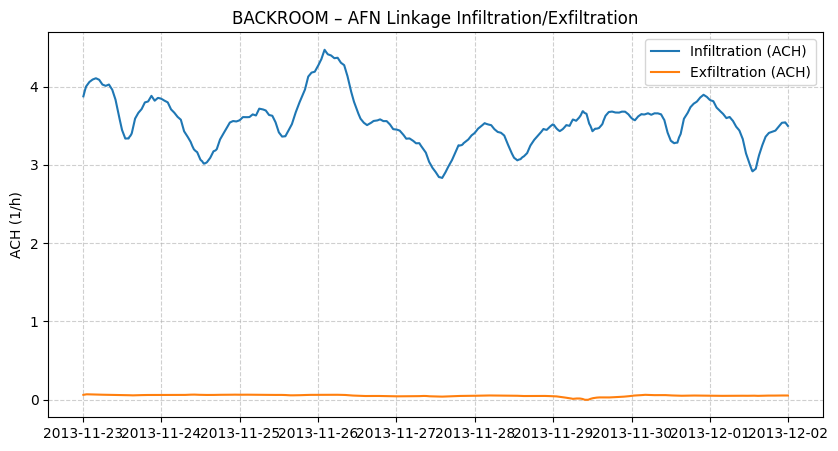

Mean infiltration ACH: 3.549
Mean exfiltration ACH: 0.053


In [6]:
zone = "BACKROOM"
rho = 1.2
vol = zone_volumes[zone.upper()]


measured_inf = {"FRONT_ROOM":0.23,"BACKROOM":0.55,"KITCHEN":1.65,"HALL_DOWNSTAIRS":2.02,"HALL_UPSTAIRS":0.02,"BEDROOM_1":0.0,"BEDROOM_2":0.0,"BEDROOM_3":0.15,"BATHROOM":0.02,"SUBFLOOR":21.0,"LOFT":0.0}
measured_exf = {"FRONT_ROOM":0.37,"BACKROOM":0.05,"KITCHEN":0.25,"HALL_DOWNSTAIRS":0.18,"HALL_UPSTAIRS":1.28,"BEDROOM_1":0.6,"BEDROOM_2":1.7,"BEDROOM_3":2.15,"BATHROOM":1.88,"SUBFLOOR":0,"LOFT":2.1}

infil_total = pd.Series(0.0, index=df.index)
exfil_total = pd.Series(0.0, index=df.index)

for sf in zone_links[zone.upper()]:
    infil = df[f"{sf.upper()}:AFN Linkage Node 2 to Node 1 Mass Flow Rate [kg/s](TimeStep)"].clip(lower=0)
    exfil = df[f"{sf.upper()}:AFN Linkage Node 1 to Node 2 Mass Flow Rate [kg/s](TimeStep)"].clip(lower=0)
    infil_total += infil
    exfil_total += exfil

# Convert to ACH (1/h)
infil_ach = (infil_total / (rho * vol)) * 3600
exfil_ach = (exfil_total / (rho * vol)) * 3600

# Plot
plt.figure(figsize=(10,5))
plt.plot(infil_ach, label="Infiltration (ACH)")
plt.plot(exfil_ach, label="Exfiltration (ACH)")
plt.title(f"{zone} – AFN Linkage Infiltration/Exfiltration")
plt.ylabel("ACH (1/h)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Mean infiltration ACH:", round(infil_ach.mean(), 3))
print("Mean exfiltration ACH:", round(exfil_ach.mean(), 3))


In [7]:
zone_links

{'HALL_DOWNSTAIRS': ['Block hall_downstairs Storey 0 Wall 0003',
  'Block hall_downstairs Storey 0 Wall 0004',
  'Block hall_downstairs Storey 0 Wall 0004_extdoor'],
 'FRONT_ROOM': ['Block front_room Storey 0 Wall 0004',
  'Block front_room Storey 0 Wall 0004_window'],
 'KITCHEN': ['Block kitchen Storey 0 Wall 0002',
  'Block kitchen Storey 0 Wall 0003',
  'Block kitchen Storey 0 Wall 0002_window',
  'Block kitchen Storey 0 Wall 0003_extdoor'],
 'BACKROOM': ['Block backroom Storey 0 Wall 0002',
  'Block backroom Storey 0 Wall 0002_window',
  'Block backroom Storey 0 Wall 0002_extdoor'],
 'BEDROOM_3': ['Block bedroom_3 Storey 0 Wall 0003',
  'Block bedroom_3 Storey 0 Wall 0004',
  'Block bedroom_3 Storey 0 Wall 0004_window'],
 'BEDROOM_1': ['Block bedroom_1 Storey 0 Wall 0004',
  'Block bedroom_1 Storey 0 Wall 0004_window'],
 'HALL_UPSTAIRS': ['Block hall_upstairs Storey 0 Wall 0003'],
 'BATHROOM': ['Block bathroom Storey 0 Wall 0002',
  'Block bathroom Storey 0 Wall 0003',
  'Block bat

                 AFN_infil  AFN_exfil  Eplus_infil  Measured_infil  \
Zone                                                                 
HALL_DOWNSTAIRS      2.221      0.000        2.425            2.02   
FRONT_ROOM           1.490      0.000        1.562            0.23   
KITCHEN              3.682      0.000        3.861            1.65   
BACKROOM             3.496      0.000        3.591            0.55   
BEDROOM_3            0.000      2.496        0.000            0.15   
BEDROOM_1            0.000      6.360        0.000            0.00   
HALL_UPSTAIRS        0.000      0.457        0.000            0.02   
BATHROOM             0.000      3.709        0.000            0.02   
BEDROOM_2            0.000      2.467        0.000            0.00   
SUBFLOOR            18.569      0.000       18.117           21.00   
LOFT                 0.000      1.450        0.000            0.00   

                 Measured_exfil  
Zone                             
HALL_DOWNSTAIRS      

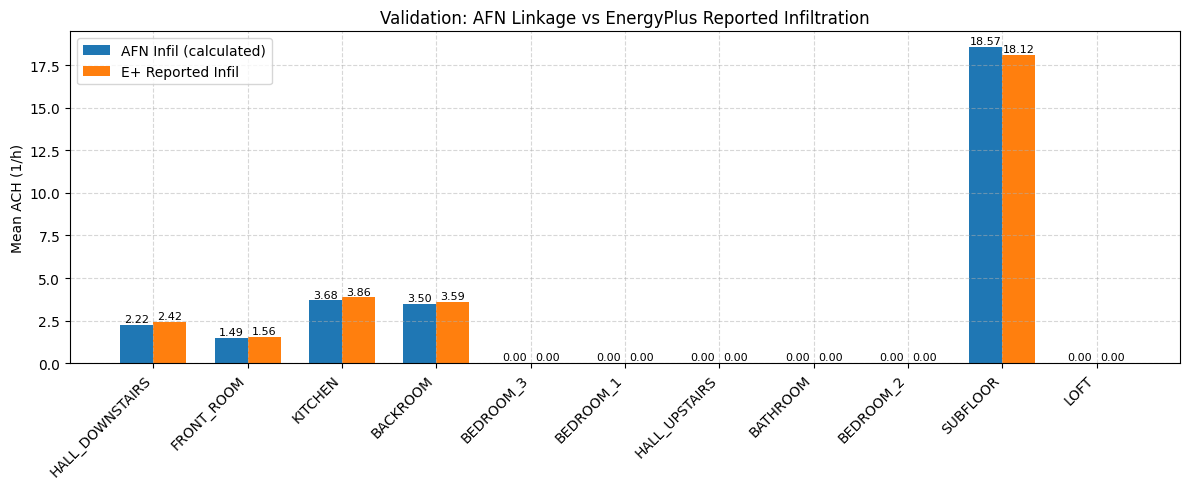

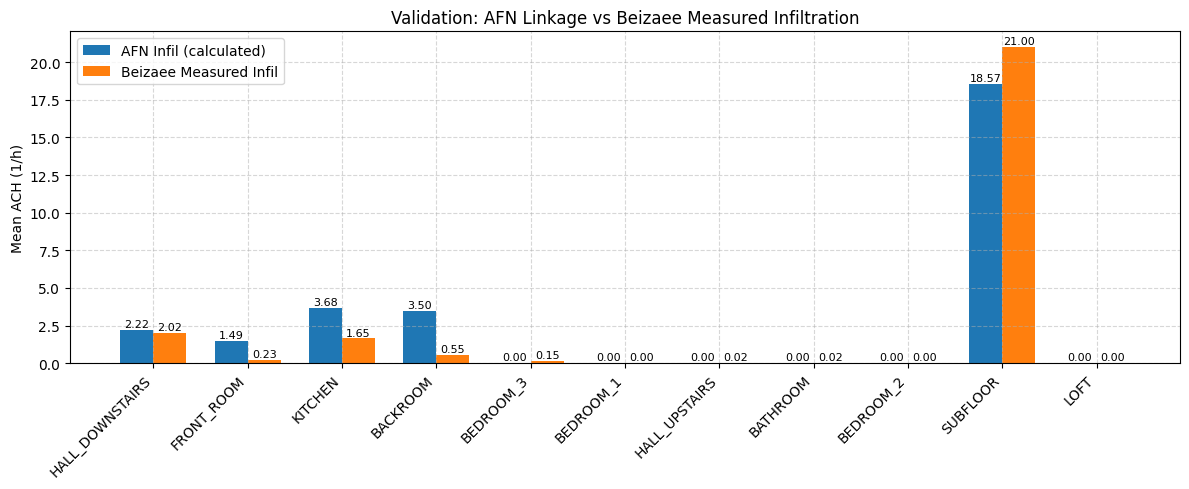

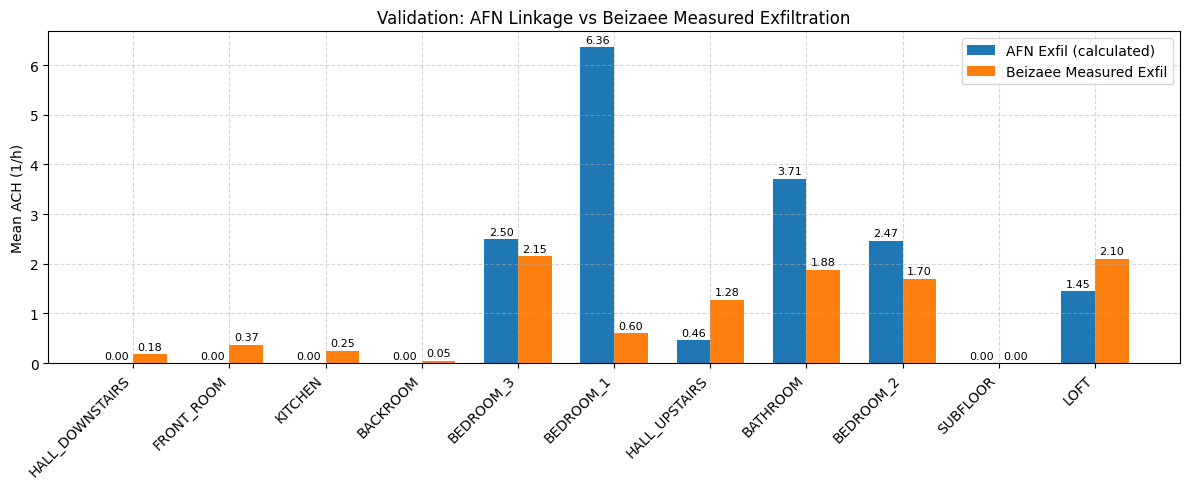

In [8]:

rho = 1.2
ach_means = []

for zone in zone_links.keys():
    vol = zone_volumes[zone.upper()]
    net_flow = pd.Series(0.0, index=df.index)

    for sf in zone_links[zone.upper()]:
        # Node 2->1: typically INTO the zone (positive infiltration)
        # Node 1->2: typically OUT of the zone (positive exfiltration)
        flow_21 = df[f"{sf.upper()}:AFN Linkage Node 2 to Node 1 Mass Flow Rate [kg/s](TimeStep)"]
        flow_12 = df[f"{sf.upper()}:AFN Linkage Node 1 to Node 2 Mass Flow Rate [kg/s](TimeStep)"]

        # Net flow INTO zone (positive = infiltration, negative = exfiltration)
        net_flow += (flow_21 - flow_12)

    # Split into infiltration and exfiltration
    infil_total = net_flow.clip(lower=0)
    exfil_total = (-net_flow).clip(lower=0)

    infil_ach = (infil_total / (rho * vol)) * 3600
    exfil_ach = (exfil_total / (rho * vol)) * 3600
    eplus_col = f"{zone.upper()}:AFN Zone Infiltration Air Change Rate [ach](TimeStep)"
    eplus_infil_ach = df[eplus_col] if eplus_col in df.columns else pd.Series(np.nan, index=df.index)
    ach_means.append({
        "Zone": zone.upper(),
        "AFN_infil": infil_ach.mean(),
        "AFN_exfil": exfil_ach.mean(),
        "Eplus_infil": eplus_infil_ach.mean(),
        "Measured_infil": measured_inf.get(zone.upper(), np.nan),
        "Measured_exfil": measured_exf.get(zone.upper(), np.nan)
    })

ach_df = pd.DataFrame(ach_means).set_index("Zone").round(3)
print(ach_df)


def bar_compare(df, col1, col2, label1, label2, title):
    zones = df.index
    x = np.arange(len(zones))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12,5))
    ax.bar(x - w/2, df[col1], width=w, label=label1)
    ax.bar(x + w/2, df[col2], width=w, label=label2)
    for i, zone in enumerate(zones):
        v1, v2 = df.loc[zone, col1], df.loc[zone, col2]
        if not np.isnan(v1): ax.text(i - w/2, v1 + 0.05, f"{v1:.2f}", ha='center', va='bottom', fontsize=8)
        if not np.isnan(v2): ax.text(i + w/2, v2 + 0.05, f"{v2:.2f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(zones, rotation=45, ha="right")
    ax.set_ylabel("Mean ACH (1/h)")
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()


# 1️⃣ AFN-calculated vs EnergyPlus infiltration
bar_compare(ach_df, "AFN_infil", "Eplus_infil",
            "AFN Infil (calculated)", "E+ Reported Infil",
            "Validation: AFN Linkage vs EnergyPlus Reported Infiltration")

# 2️⃣ AFN-calculated infiltration vs Beizaee measured
bar_compare(ach_df, "AFN_infil", "Measured_infil",
            "AFN Infil (calculated)", "Beizaee Measured Infil",
            "Validation: AFN Linkage vs Beizaee Measured Infiltration")

# 3️⃣ AFN-calculated exfiltration vs Beizaee measured
bar_compare(ach_df, "AFN_exfil", "Measured_exfil",
            "AFN Exfil (calculated)", "Beizaee Measured Exfil",
            "Validation: AFN Linkage vs Beizaee Measured Exfiltration")
